# Comprehensive Data Analysis & Label Verification

This notebook performs a rigorous Exploratory Data Analysis (EDA) on the gunshot audio dataset.
**Before we touch any supervised learning algorithm**, we must verify:

1. **Data Discovery** — File counts, directory structure, per-source breakdown
2. **Duration Analysis** — Histograms showing the natural duration of events
3. **Anomaly Detection** — Scan for silent, corrupt, or zero-length files
4. **Waveform Visualization** — Visual comparison of Class 0 vs. Class 1 signals
5. **Spectrogram Visualization** — Mel spectrograms to verify label quality
6. **Feature Distributions** — MFCC coefficient histograms by class
7. **Class Separability** — PCA and t-SNE 2D projections to confirm classes separate

### Label Mapping
| Label | Folders | Description |
|-------|---------|-------------|
| **1** | `Data/gun`, `Data/edge-collected-gunshot-audio` | Gunshot audio |
| **0** | `Data/audio`, `Data/sound` | Ambient / background noise |

In [1]:
%pip install -q librosa soundfile pandas numpy matplotlib seaborn scikit-learn tqdm ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
print('All imports loaded.')

All imports loaded.


---
## Step 1: Data Discovery
Scan all source directories, count `.wav` files per class and per folder.

In [3]:
def resolve_data_root():
    """Walk up from cwd to find the project's Data/ folder."""
    current = Path.cwd().resolve()
    expected_subdirs = ('edge-collected-gunshot-audio', 'gun', 'audio', 'sound')
    best_data_dir = None
    best_score = -1
    best_depth = 10**9

    for candidate in [current, *current.parents]:
        data_dir = candidate / 'Data'
        if not data_dir.exists():
            continue
        score = sum((data_dir / subdir).exists() for subdir in expected_subdirs)
        depth = len(data_dir.parts)
        if score > best_score or (score == best_score and depth < best_depth):
            best_data_dir = data_dir
            best_score = score
            best_depth = depth

    if best_data_dir is None:
        raise FileNotFoundError("Could not locate a valid Data folder.")

    return best_data_dir, best_score

BASE_DIR, DATA_MATCH_SCORE = resolve_data_root()
PROJECT_ROOT = BASE_DIR.parent

# Handle edge-collected nested directory structure
EDGE_ROOT = BASE_DIR / 'edge-collected-gunshot-audio'
EDGE_NESTED = EDGE_ROOT / 'edge-collected-gunshot-audio'
EDGE_DIR = EDGE_NESTED if EDGE_NESTED.exists() else EDGE_ROOT

# Class directory mapping
CLASS_MAP = {
    1: [BASE_DIR / 'gun', EDGE_DIR],             # Gunshot
    0: [BASE_DIR / 'audio', BASE_DIR / 'sound'],  # Ambient/Noise
}

def _is_macos_junk(filepath):
    """Return True if a path is a macOS resource-fork metadata file.
    These are NOT valid audio and live inside __MACOSX dirs with ._ prefixed names."""
    path_str = str(filepath)
    if '__MACOSX' in path_str:
        return True
    if filepath.name.startswith('._'):
        return True
    return False

def collect_wav_files(directories, label):
    """Recursively collect all .wav paths from a list of directories.
    Filters out macOS metadata junk files (__MACOSX and ._ prefixed)."""
    files = []
    skipped = 0
    for d in directories:
        if not d.exists():
            print(f'  [WARN] Missing: {d}')
            continue
        for wav in sorted(d.rglob('*.wav')):
            if _is_macos_junk(wav):
                skipped += 1
                continue
            files.append({'path': str(wav), 'label': label, 'source_dir': d.name})
    if skipped > 0:
        print(f'  [INFO] Filtered {skipped} macOS junk files from label={label}')
    return files

all_records = []
for label, dirs in CLASS_MAP.items():
    all_records.extend(collect_wav_files(dirs, label))

df = pd.DataFrame(all_records)

print(f'Project root : {PROJECT_ROOT}')
print(f'Data root    : {BASE_DIR} (match score: {DATA_MATCH_SCORE}/4)')
print()
print('=' * 50)
print('         FILE COUNT SUMMARY')
print('=' * 50)
for label in sorted(df['label'].unique()):
    cls_name = 'Gunshot' if label == 1 else 'Ambient/Noise'
    count = len(df[df['label'] == label])
    print(f'  Class {label} ({cls_name:14s}): {count:,}')
print(f'  {"Total":22s}: {len(df):,}')
print('=' * 50)

print('\nPer-directory breakdown:')
summary = df.groupby(['label', 'source_dir']).size().reset_index(name='count')
print(summary.to_string(index=False))


  [INFO] Filtered 413 macOS junk files from label=1
Project root : C:\Desktop\Data-Cleaner
Data root    : C:\Desktop\Data-Cleaner\Data (match score: 4/4)

         FILE COUNT SUMMARY
  Class 0 (Ambient/Noise ): 6,230
  Class 1 (Gunshot       ): 4,138
  Total                 : 10,368

Per-directory breakdown:
 label                   source_dir  count
     0                        audio   6000
     0                        sound    230
     1 edge-collected-gunshot-audio   2148
     1                          gun   1990


---
## Step 2: Duration Analysis
Measure the natural duration of every audio file and plot per-class histograms.

In [4]:
print('Scanning file durations (this may take a few minutes)...')
durations = []
read_errors = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc='Duration scan'):
    try:
        dur = librosa.get_duration(path=row['path'])
        durations.append(dur)
    except Exception as e:
        durations.append(np.nan)
        read_errors.append({'path': row['path'], 'error': str(e)})

df['duration_s'] = durations

if read_errors:
    print(f'\n  {len(read_errors)} files could not be read:')
    for e in read_errors[:10]:
        print(f'    {e["path"]}: {e["error"]}')

# Statistics
print('\n=== Duration Statistics (seconds) ===')
for label in sorted(df['label'].unique()):
    cls_name = 'Gunshot' if label == 1 else 'Ambient'
    subset = df[df['label'] == label]['duration_s'].dropna()
    print(f'\n  Class {label} ({cls_name}):')
    print(f'    Count : {len(subset):,}')
    print(f'    Min   : {subset.min():.3f}')
    print(f'    Max   : {subset.max():.3f}')
    print(f'    Mean  : {subset.mean():.3f}')
    print(f'    Median: {subset.median():.3f}')
    print(f'    Std   : {subset.std():.3f}')

Scanning file durations (this may take a few minutes)...


Duration scan:   0%|          | 0/10368 [00:00<?, ?it/s]


=== Duration Statistics (seconds) ===

  Class 0 (Ambient):
    Count : 6,230
    Min   : 4.280
    Max   : 5.000
    Mean  : 5.000
    Median: 5.000
    Std   : 0.011

  Class 1 (Gunshot):
    Count : 4,138
    Min   : 1.393
    Max   : 13.121
    Mean  : 3.285
    Median: 2.323
    Std   : 1.723


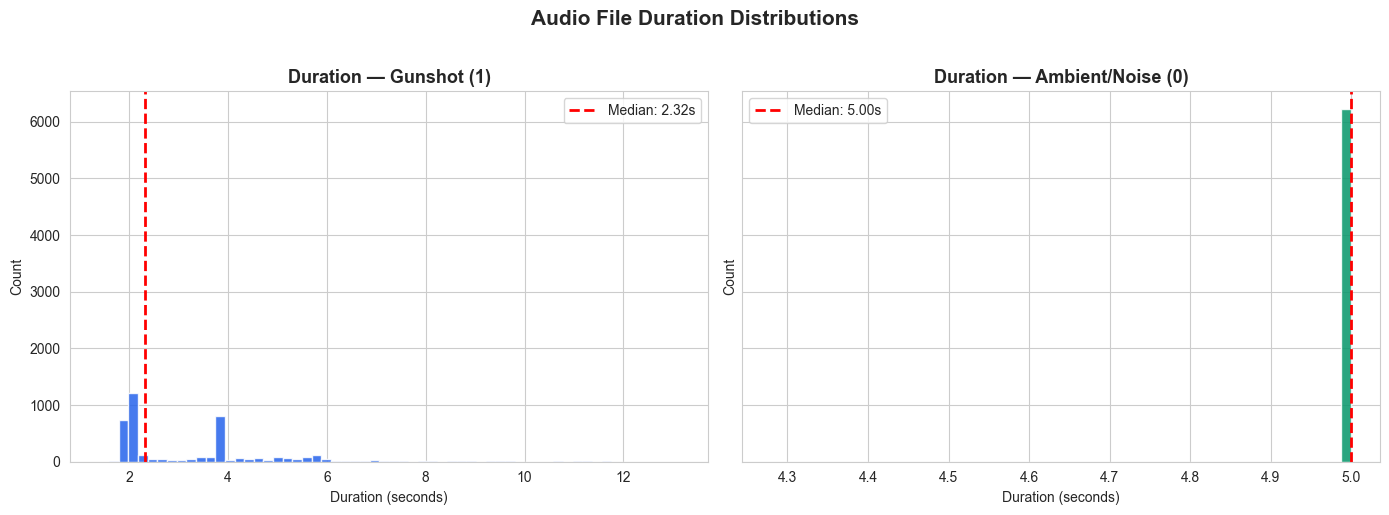

In [5]:
# Duration Histograms
colors = {0: '#059669', 1: '#2563eb'}
label_names = {0: 'Ambient/Noise (0)', 1: 'Gunshot (1)'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, label in zip(axes, [1, 0]):
    subset = df[df['label'] == label]['duration_s'].dropna()
    ax.hist(subset, bins=60, color=colors[label], alpha=0.85, edgecolor='white')
    ax.axvline(subset.median(), color='red', linestyle='--', lw=2,
               label=f'Median: {subset.median():.2f}s')
    ax.set_title(f'Duration \u2014 {label_names[label]}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Duration (seconds)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=10)

plt.suptitle('Audio File Duration Distributions', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 3: Anomaly Detection
Scan a sample of files for silent, corrupt, or zero-length audio.

In [6]:
SCAN_LIMIT = 2000  # Max files per class to deep-scan

print(f'Scanning up to {SCAN_LIMIT:,} files per class for anomalies...')
anomalies = []

for label in [0, 1]:
    subset = df[df['label'] == label]
    sample = subset.sample(n=min(SCAN_LIMIT, len(subset)), random_state=SEED)

    for _, row in tqdm(sample.iterrows(), total=len(sample),
                       desc=f'Class {label} anomaly scan'):
        try:
            y, sr = librosa.load(row['path'], sr=22050, duration=5.0)
            max_amp = float(np.max(np.abs(y)))
            if len(y) == 0:
                anomalies.append({'path': row['path'], 'label': label,
                                  'issue': 'Empty file', 'max_amp': 0})
            elif max_amp < 0.001:
                anomalies.append({'path': row['path'], 'label': label,
                                  'issue': 'Nearly silent', 'max_amp': max_amp})
        except Exception as e:
            anomalies.append({'path': row['path'], 'label': label,
                              'issue': f'Load error: {e}', 'max_amp': np.nan})

if anomalies:
    df_anom = pd.DataFrame(anomalies)
    print(f'\nFound {len(anomalies)} anomalous files:')
    print(df_anom[['path', 'label', 'issue', 'max_amp']].to_string(index=False))
else:
    print('\nNo anomalous (silent/corrupt) files detected in scanned sample!')

Scanning up to 2,000 files per class for anomalies...


Class 0 anomaly scan:   0%|          | 0/2000 [00:00<?, ?it/s]

Class 1 anomaly scan:   0%|          | 0/2000 [00:00<?, ?it/s]


No anomalous (silent/corrupt) files detected in scanned sample!


---
## Step 4: Waveform Visualization
Plot raw waveforms from random samples of each class to visually verify labels.

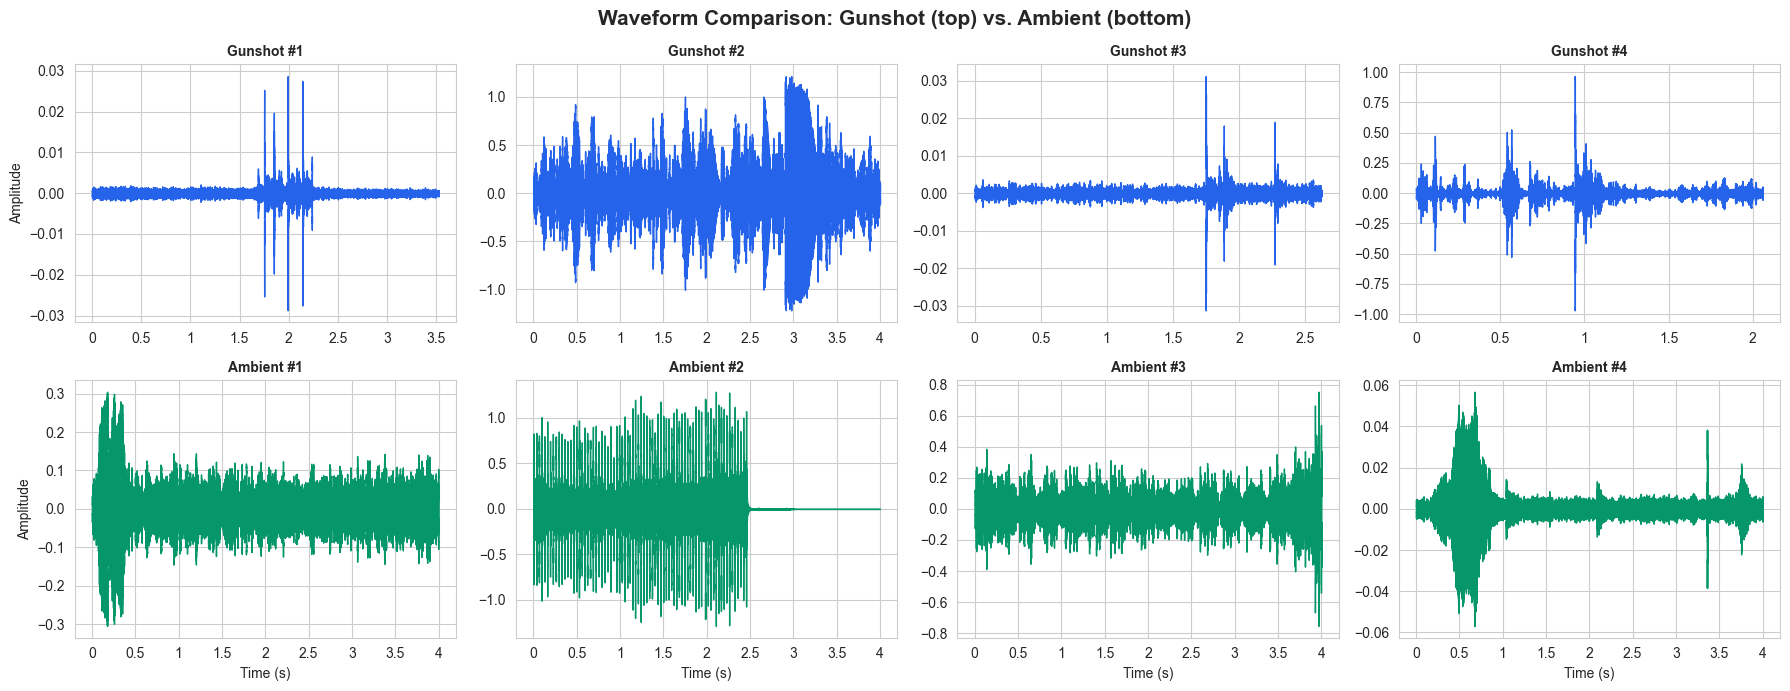

In [7]:
N_SAMPLES = 4

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(18, 7))
fig.suptitle('Waveform Comparison: Gunshot (top) vs. Ambient (bottom)',
             fontsize=15, fontweight='bold')

for row_idx, label in enumerate([1, 0]):
    subset = df[df['label'] == label].sample(n=N_SAMPLES, random_state=SEED)
    cls_name = 'Gunshot' if label == 1 else 'Ambient'

    for col_idx, (_, file_row) in enumerate(subset.iterrows()):
        y, sr = librosa.load(file_row['path'], sr=22050, duration=4.0)
        ax = axes[row_idx, col_idx]
        librosa.display.waveshow(y, sr=sr, ax=ax, color=colors[label])
        ax.set_title(f'{cls_name} #{col_idx+1}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Time (s)' if row_idx == 1 else '')
        if col_idx == 0:
            ax.set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

---
## Step 5: Mel Spectrogram Visualization
Mel spectrograms reveal frequency patterns \u2014 gunshots typically show a sharp broadband impulse.

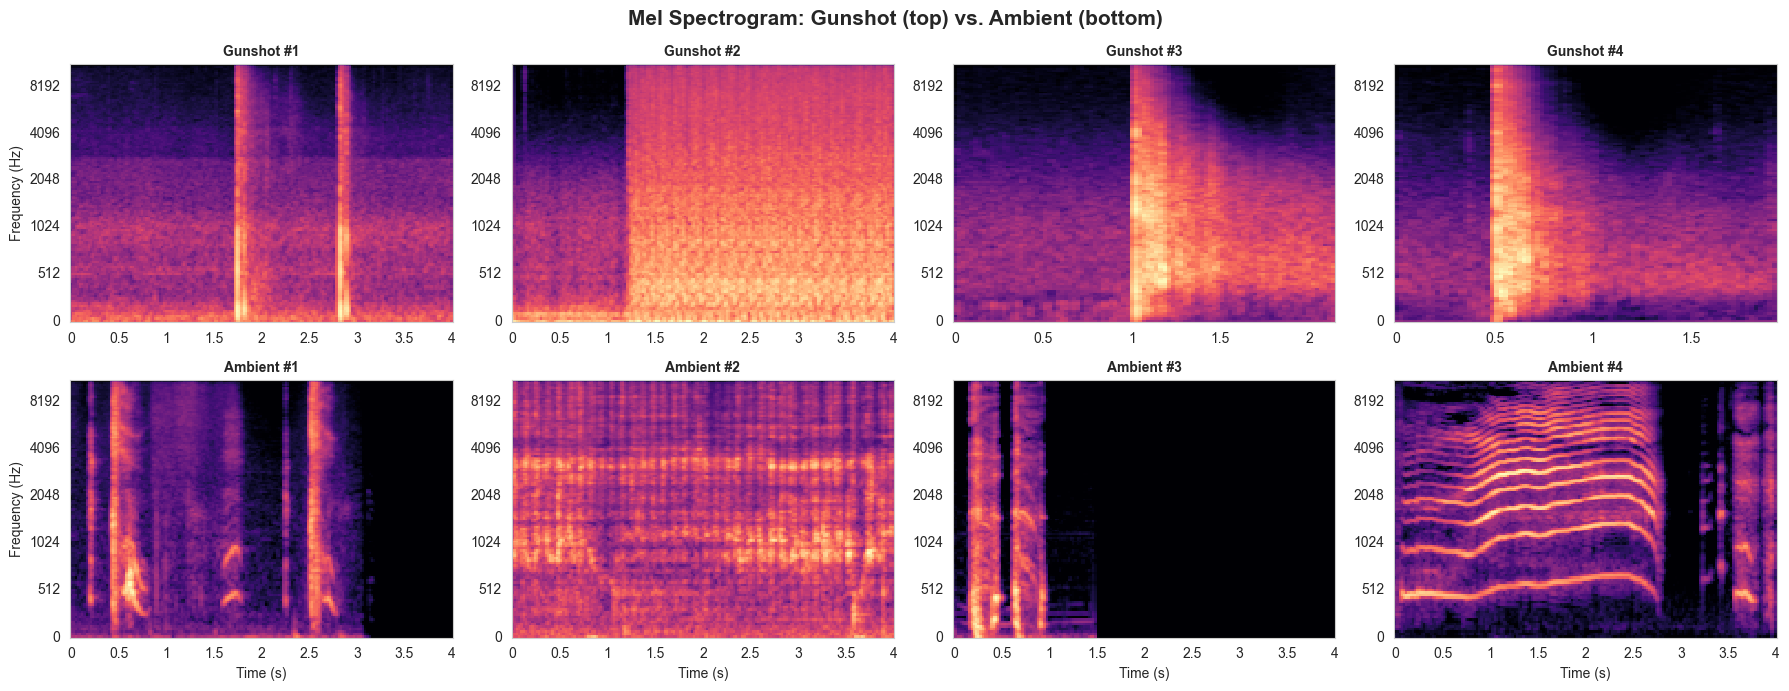

In [8]:
fig, axes = plt.subplots(2, N_SAMPLES, figsize=(18, 7))
fig.suptitle('Mel Spectrogram: Gunshot (top) vs. Ambient (bottom)',
             fontsize=15, fontweight='bold')

for row_idx, label in enumerate([1, 0]):
    subset = df[df['label'] == label].sample(n=N_SAMPLES, random_state=SEED + 1)
    cls_name = 'Gunshot' if label == 1 else 'Ambient'

    for col_idx, (_, file_row) in enumerate(subset.iterrows()):
        y, sr = librosa.load(file_row['path'], sr=22050, duration=4.0)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)
        ax = axes[row_idx, col_idx]
        librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel',
                                ax=ax, cmap='magma')
        ax.set_title(f'{cls_name} #{col_idx+1}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Time (s)' if row_idx == 1 else '')
        if col_idx == 0:
            ax.set_ylabel('Frequency (Hz)')
        else:
            ax.set_ylabel('')

plt.tight_layout()
plt.show()

---
## Step 6: MFCC Feature Extraction & Distribution
Extract 40 MFCCs (mean + std = 80 features) from a sample and plot how
the first coefficients distribute across classes.

In [9]:
SAMPLE_PER_CLASS = 400
N_MFCC = 40
TARGET_SR = 22050
TARGET_DURATION = 4.0  # seconds

print(f'Extracting {N_MFCC} MFCCs from {SAMPLE_PER_CLASS} samples per class...')

features = []
feature_labels = []

for label in [0, 1]:
    subset = df[df['label'] == label]
    sample_n = min(SAMPLE_PER_CLASS, len(subset))
    sample = subset.sample(n=sample_n, random_state=SEED)

    for _, row in tqdm(sample.iterrows(), total=len(sample),
                       desc=f'Class {label} MFCCs'):
        try:
            y, sr = librosa.load(row['path'], sr=TARGET_SR, duration=TARGET_DURATION)
            if len(y) < sr * 0.1:  # skip very short clips
                continue
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
            mfcc_mean = np.mean(mfccs, axis=1)
            mfcc_std = np.std(mfccs, axis=1)
            features.append(np.concatenate([mfcc_mean, mfcc_std]))
            feature_labels.append(label)
        except Exception:
            continue

X_feat = np.array(features)
y_feat = np.array(feature_labels)

print(f'\nFeature matrix shape: {X_feat.shape}')
print(f'  Class 0 samples: {np.sum(y_feat == 0)}')
print(f'  Class 1 samples: {np.sum(y_feat == 1)}')

Extracting 40 MFCCs from 400 samples per class...


Class 0 MFCCs:   0%|          | 0/400 [00:00<?, ?it/s]

Class 1 MFCCs:   0%|          | 0/400 [00:00<?, ?it/s]


Feature matrix shape: (800, 80)
  Class 0 samples: 400
  Class 1 samples: 400


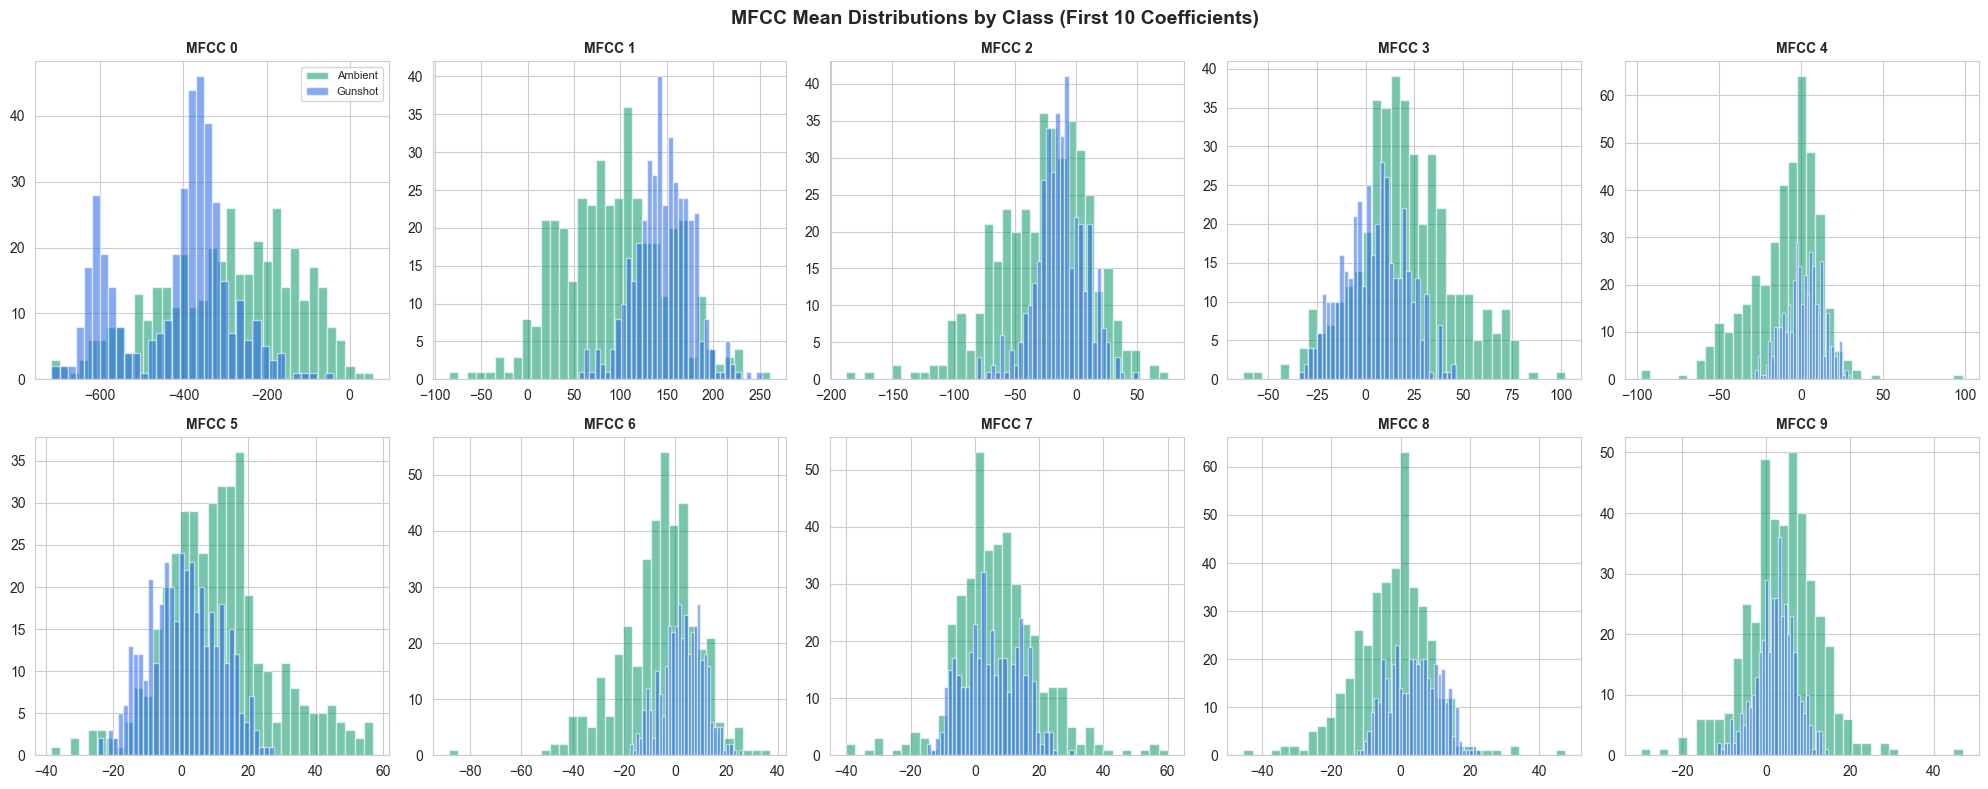

In [10]:
# Plot MFCC Mean distributions for first 10 coefficients
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('MFCC Mean Distributions by Class (First 10 Coefficients)',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    for label in [0, 1]:
        mask = y_feat == label
        cls_name = 'Gunshot' if label == 1 else 'Ambient'
        ax.hist(X_feat[mask, i], bins=35, alpha=0.55, label=cls_name,
                color=colors[label], edgecolor='white')
    ax.set_title(f'MFCC {i}', fontsize=10, fontweight='bold')
    if i == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Step 7: Class Separability (PCA & t-SNE)
Reduce the 80-dimensional MFCC feature space to 2D and visualize whether
the two classes form distinct clusters.

In [12]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)

# PCA
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
print('Running t-SNE (this may take a minute)...')
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print('Done.')

Running t-SNE (this may take a minute)...
Done.


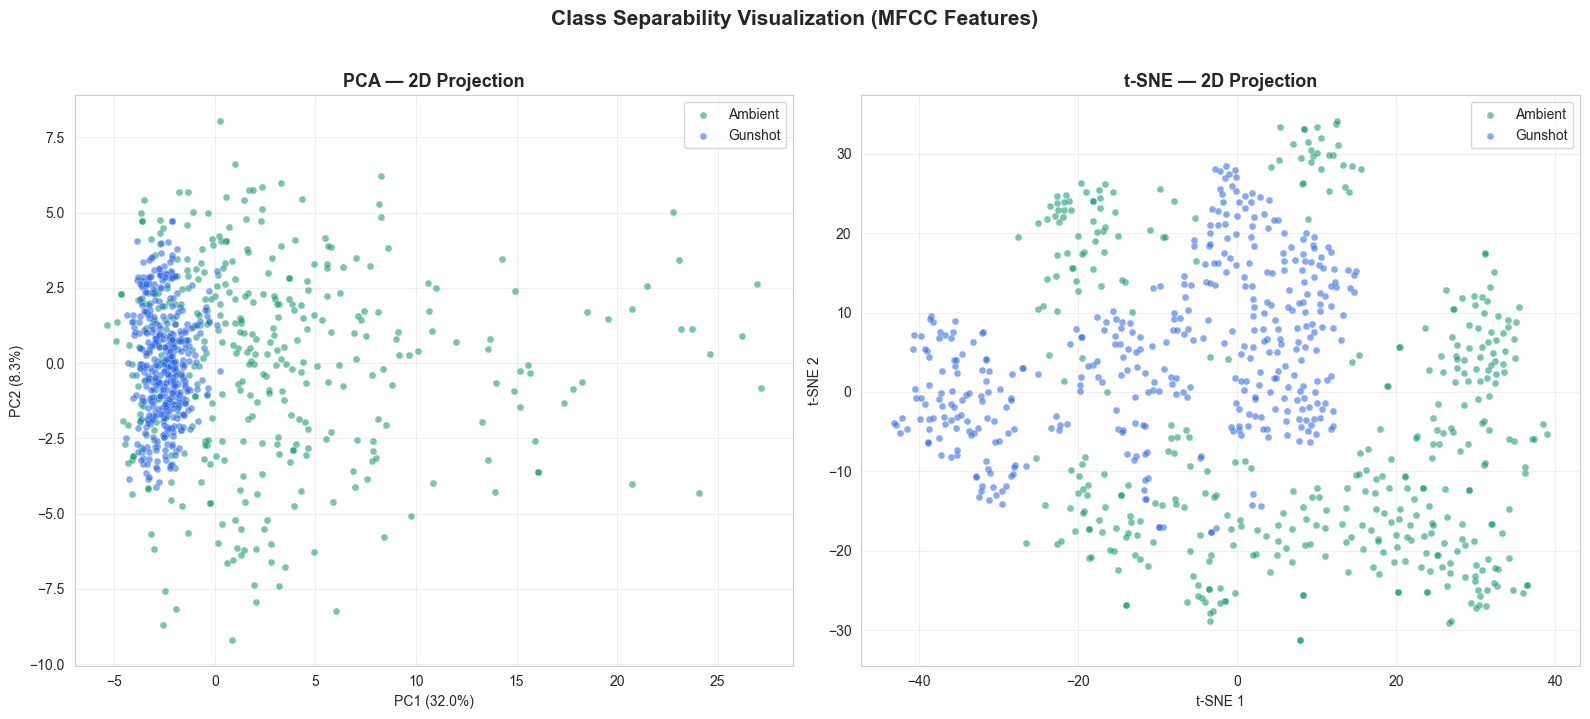


PCA explained variance: PC1=32.0%, PC2=8.3%, Total=40.3%


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# PCA plot
for label in [0, 1]:
    mask = y_feat == label
    cls_name = 'Gunshot' if label == 1 else 'Ambient'
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[label], alpha=0.55,
               s=25, label=cls_name, edgecolors='white', linewidths=0.3)
ax1.set_title('PCA \u2014 2D Projection', fontsize=13, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# t-SNE plot
for label in [0, 1]:
    mask = y_feat == label
    cls_name = 'Gunshot' if label == 1 else 'Ambient'
    ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[label], alpha=0.55,
               s=25, label=cls_name, edgecolors='white', linewidths=0.3)
ax2.set_title('t-SNE \u2014 2D Projection', fontsize=13, fontweight='bold')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Class Separability Visualization (MFCC Features)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nPCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, '
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%, '
      f'Total={sum(pca.explained_variance_ratio_)*100:.1f}%')

---
## Summary & Next Steps

After reviewing all the visualizations above, you should be able to confirm:

- **Are the labels correct?** Waveforms and spectrograms for Class 1 should show sharp, impulsive gunshot patterns vs. continuous ambient noise for Class 0.
- **Are there problematic files?** The anomaly scan will flag silent or corrupt files that need removal.
- **Do the classes separate?** If the PCA/t-SNE plots show distinct clusters, supervised classifiers will likely perform well.

### After confirming the above, proceed to:
1. Run `prep_trim.ipynb` \u2192 `prep_csv.ipynb` \u2192 `prep_bal.ipynb` to build the balanced dataset.
2. Run `rf_eval.ipynb` and `svm_eval.ipynb` for full model evaluation.
3. Consider additional algorithms (KNN, Logistic Regression, Gradient Boosting) in Phase 2.